In [1]:
import yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
with open("../config.yaml",'r') as file:
    config = yaml.safe_load(file)

In [12]:
data = pd.read_csv(config['data']['raw']['file8'], quotechar='"', sep = "\t")

In [31]:
data.head(), data.shape, data.ID.nunique()

AttributeError: 'DataFrame' object has no attribute 'ID'

In [34]:
data.isna().sum()

Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
age                    0
Num_Children           0
Has_child              0
dtype: int64

In [33]:
data = data.dropna(subset=['Income'])

In [16]:
data = data.drop(columns=['ID'])

In [17]:
data['age']= 2014-data.Year_Birth

In [18]:
data.Education.value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [19]:
data['Education']=data['Education'].replace({'Basic':'Undergraduate','2n Cycle':'Undergraduate','Graduation':'Postgraduate','Master':'Postgraduate','PhD':'PhD'})

In [24]:
data.Marital_Status.value_counts()

Marital_Status
Partnered    1444
Single        487
Separated     309
Name: count, dtype: int64

In [23]:
data['Marital_Status']=data['Marital_Status'].replace({'Divorced':'Separated','Alone':'Single','Married':'Partnered','Together':'Partnered','Absurd':'Single','Widow':'Separated','YOLO':'Single'})

<Axes: ylabel='Income'>

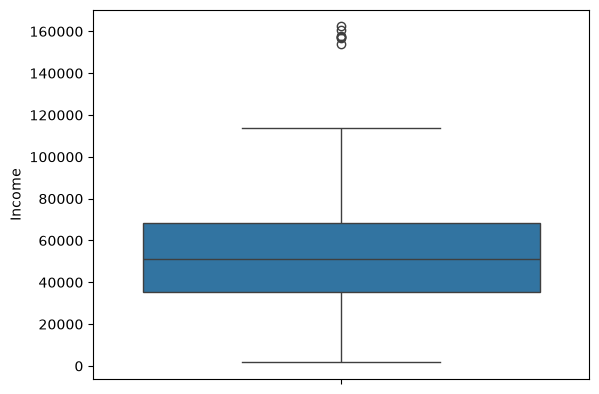

In [35]:
sns.boxplot(data=data,y='Income')

In [26]:
# extreme outlier
outlier_idx = np.where([data.Income==data.Income.max()])
data = data.drop(outlier_idx[1])

In [43]:
data['Num_Children'] = data.Kidhome + data.Teenhome
data = data.drop(columns=['Kidhome','Teenhome'])

In [29]:
data['Has_child']= data.Num_Children> 0

In [30]:
data.Has_child.value_counts()

Has_child
True     1601
False     638
Name: count, dtype: int64

In [41]:
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], dayfirst=True,format = '%d-%m-%Y')
baseline_date = pd.to_datetime('2014-07-01')
data['Customer_Tenure_in_Days'] = (baseline_date - data['Dt_Customer']).dt.days
data = data.drop(columns=['Dt_Customer'])

In [45]:
data=data.rename(columns={'MntWines': "Wines",'MntFruits':'Fruits','MntMeatProducts':'Meat','MntFishProducts':'Fish','MntSweetProducts':'Sweets','MntGoldProds':'Gold'})

In [46]:
data['total_spend']=data['Wines']+data['Fruits']+data['Meat']+data['Fish']+data['Sweets']+data['Gold']

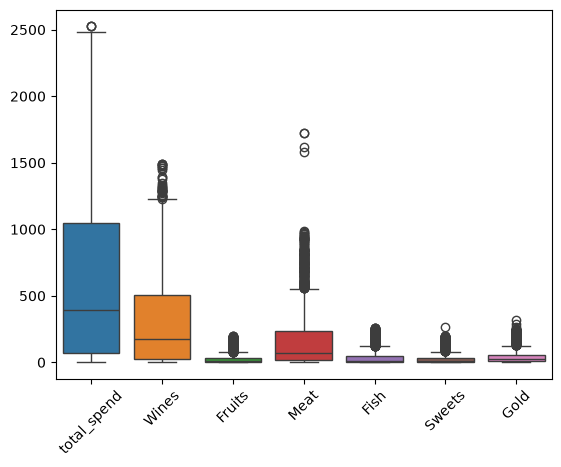

In [51]:
cols = ['total_spend', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']

sns.boxplot(data=data[cols])
plt.xticks(rotation=45)
plt.show()

In [52]:
data=data.rename(columns={'NumDealsPurchases': "Deals",'NumWebPurchases':'Web','NumCatalogPurchases':'Catalogue','NumStorePurchases':'Store','NumWebVisitsMonth':'WebVisits'})

In [55]:
data.nunique()

Year_Birth                   59
Education                     3
Marital_Status                3
Income                     1973
Recency                     100
Wines                       776
Fruits                      158
Meat                        554
Fish                        182
Sweets                      176
Gold                        212
Deals                        15
Web                          15
Catalogue                    14
Store                        14
WebVisits                    16
AcceptedCmp3                  2
AcceptedCmp4                  2
AcceptedCmp5                  2
AcceptedCmp1                  2
AcceptedCmp2                  2
Complain                      2
Z_CostContact                 1
Z_Revenue                     1
Response                      2
age                          59
Num_Children                  4
Has_child                     2
Customer_Tenure_in_Days     662
total_spend                1047
dtype: int64

In [56]:
data.Z_Revenue.unique(), data.Z_CostContact.unique()

(array([11]), array([3]))

In [58]:
data.AcceptedCmp1.unique()

array([0, 1])

In [59]:
data['Num_Camp_Success'] = data[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis=1)

In [60]:
data= data.drop(columns=['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'])

In [57]:
data = data.drop(columns=['Z_Revenue','Z_CostContact'])

In [65]:
data.dtypes

year_birth                   int64
education                      str
marital_status                 str
income                     float64
recency                      int64
wines                        int64
fruits                       int64
meat                         int64
fish                         int64
sweets                       int64
gold                         int64
deals                        int64
web                          int64
catalogue                    int64
store                        int64
webvisits                    int64
complain                     int64
response                     int64
age                          int64
num_children                 int64
has_child                     bool
customer_tenure_in_days      int64
total_spend                  int64
num_camp_success             int64
dtype: object

In [64]:
data.columns = data.columns.map(lambda x: x.lower())

In [66]:
data.to_csv("../data/clean/marketing_campaign.csv", index=False, encoding= "utf-8", sep = ";")